In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

Como é a malha municipal do Ceará que vamos usar pros mapas?

Total de municípios: 184
Geometrias inválidas antes: 5
Geometrias inválidas depois: 0


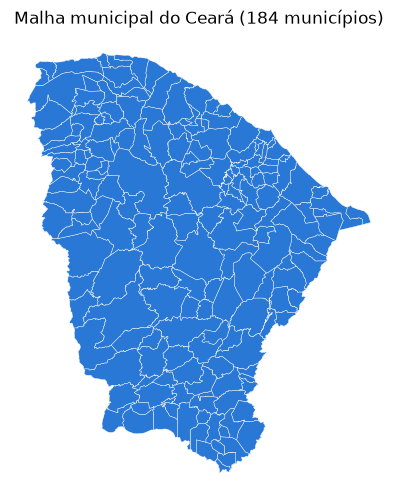

In [2]:
gdf_municipios = gpd.read_file("../dados/raw/malha_municipal_ce_2022.geojson")

print(f"Total de municípios: {gdf_municipios.shape[0]}")
print(f"Geometrias inválidas antes: {(~gdf_municipios.geometry.is_valid).sum()}")

gdf_municipios["geometry"] = gdf_municipios["geometry"].make_valid()

print(f"Geometrias inválidas depois: {(~gdf_municipios.geometry.is_valid).sum()}")

gdf_municipios.plot(figsize=(6, 6), color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.3)
plt.title("Malha municipal do Ceará (184 municípios)")
plt.axis("off")
plt.show()

In [3]:
df_ppm_raw = pd.read_csv("../dados/processed/ppm_tratado.csv")

**Regra importante (não somar espécies):** assim como no notebook principal do PPM, cada espécie (bovino, caprino, ovino, suíno, galináceos) é medida em "Cabeças" mas não são unidades equivalentes entre si. Cada mapa abaixo é de uma única espécie — nenhuma soma entre espécies é feita.

## Bovino

Qual foi o efetivo de bovino de cada município do Ceará, e como junto isso com a malha?

In [4]:
bovino_municipios_geo = df_ppm_raw[
    (df_ppm_raw["nivel_territorial_nome"] == "Município")
    & (df_ppm_raw["tipo_rebanho_nome"] == "Bovino")
].copy()
bovino_municipios_geo["territorio_codigo"] = bovino_municipios_geo["territorio_codigo"].astype(str)

bovino_municipios_geo_pivot = bovino_municipios_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

print(f"Municípios com efetivo de bovino: {bovino_municipios_geo_pivot.shape[1]}")
bovino_municipios_geo_pivot.head()

Municípios com efetivo de bovino: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,5311.0,2112.0,12048.0,40609.0,8735.0,3058.0,1715.0,15233.0,10858.0,3541.0,...,8352.0,3755.0,5987.0,9555.0,11612.0,1728.0,7038.0,2446.0,16501.0,14487.0
2004,5433.0,2174.0,6142.0,41209.0,8724.0,3097.0,2359.0,15590.0,9920.0,3513.0,...,7934.0,3811.0,6008.0,9937.0,7323.0,1816.0,7122.0,2600.0,16748.0,12960.0
2005,5615.0,2255.0,6155.0,40467.0,11519.0,3068.0,2421.0,17269.0,10020.0,3607.0,...,7975.0,3868.0,5623.0,10235.0,7433.0,1847.0,7215.0,2436.0,16700.0,12091.0
2006,5790.0,2337.0,6185.0,40062.0,12497.0,3075.0,2509.0,17442.0,10045.0,3659.0,...,8015.0,3907.0,5935.0,10542.0,7507.0,1865.0,7250.0,2495.0,16783.0,12236.0
2007,5969.0,2358.0,5998.0,41500.0,12479.0,3083.0,2701.0,29188.0,10497.0,3637.0,...,7995.0,3946.0,6385.0,10752.0,7582.0,1883.0,7281.0,2811.0,17560.0,11974.0


In [5]:
gdf_bovino = gdf_municipios.merge(
    bovino_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios_bovino = (
    bovino_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_bovino.insert(1, "nome", gdf_bovino["codarea"].map(nomes_municipios_bovino))

nao_casaram = gdf_bovino[gdf_bovino[2023].isna()]
print(f"Municípios sem valor casado: {len(nao_casaram)}")
gdf_bovino.head()

Municípios sem valor casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",5311.0,5433.0,5615.0,5790.0,5969.0,6094.0,6161.0,...,7148.0,7367.0,5830.0,8000.0,8400.0,9000.0,9010.0,9100.0,8636.0,9240.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",2112.0,2174.0,2255.0,2337.0,2358.0,2381.0,2409.0,...,1815.0,1750.0,1800.0,1150.0,1196.0,1232.0,1200.0,1253.0,2300.0,2480.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",12048.0,6142.0,6155.0,6185.0,5998.0,6088.0,6192.0,...,6856.0,6946.0,6916.0,6570.0,6438.0,6374.0,5864.0,5453.0,4962.0,5359.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",40609.0,41209.0,40467.0,40062.0,41500.0,41512.0,41516.0,...,49005.0,48024.0,43000.0,50000.0,47500.0,59039.0,65150.0,64625.0,70894.0,73900.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",8735.0,8724.0,11519.0,12497.0,12479.0,12875.0,13189.0,...,11650.0,12077.0,11875.0,14255.0,13500.0,13700.0,12604.0,12865.0,13500.0,14774.0


Como o efetivo de bovino se distribui no mapa, em 2023?

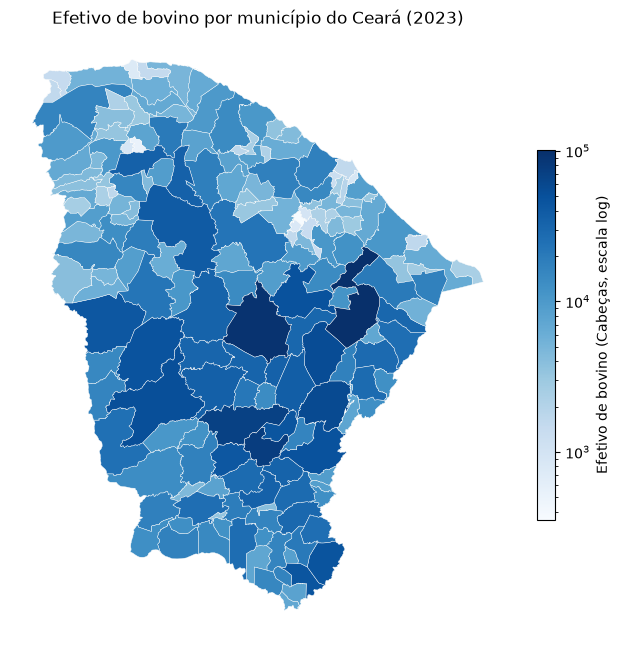

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_bovino.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_bovino[2023][gdf_bovino[2023] > 0].min(), vmax=gdf_bovino[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de bovino (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de bovino por município do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

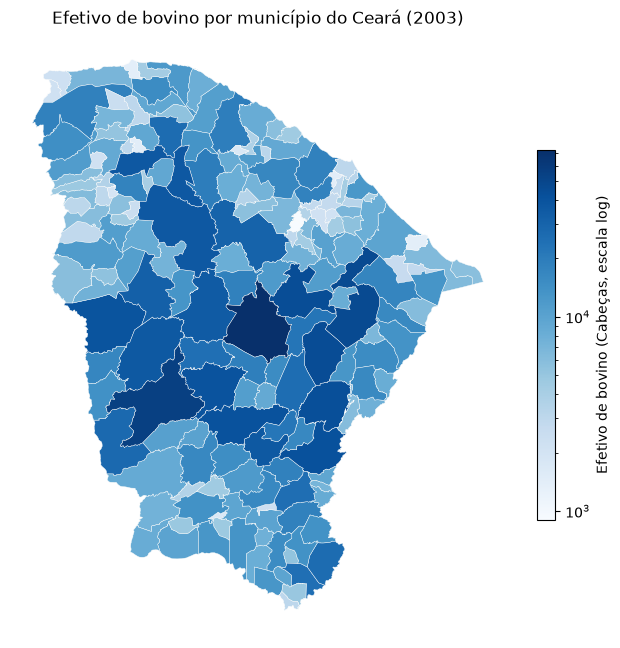

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_bovino.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_bovino[2003][gdf_bovino[2003] > 0].min(), vmax=gdf_bovino[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de bovino (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de bovino por município do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em efetivo de bovino (2003 -> 2023), no mapa?

In [8]:
gdf_bovino["crescimento"] = gdf_bovino[2023] / gdf_bovino[2003]

ranking_bovino = gdf_bovino[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking_bovino.index += 1

print("Ranking de crescimento do efetivo de bovino por município (2003 -> 2023):")
for pos, row in ranking_bovino.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

Ranking de crescimento do efetivo de bovino por município (2003 -> 2023):
  1. Jucás - CE                        2.9x
  2. Potengi - CE                      2.6x
  3. Nova Olinda - CE                  2.6x
  4. Campos Sales - CE                 2.4x
  5. Cariús - CE                       2.3x
  6. Penaforte - CE                    2.3x
  7. Milhã - CE                        2.2x
  8. Hidrolândia - CE                  2.2x
  9. Morada Nova - CE                  2.2x
 10. Várzea Alegre - CE                2.1x
 11. Frecheirinha - CE                 2.1x
 12. Iguatu - CE                       2.1x
 13. Quixelô - CE                      2.0x
 14. Crato - CE                        2.0x
 15. Farias Brito - CE                 2.0x
 16. Altaneira - CE                    2.0x
 17. Piquet Carneiro - CE              1.9x
 18. Tabuleiro do Norte - CE           1.9x
 19. Assaré - CE                       1.9x
 20. Alto Santo - CE                   1.9x
 21. Limoeiro do Norte - CE            1.9x
 2

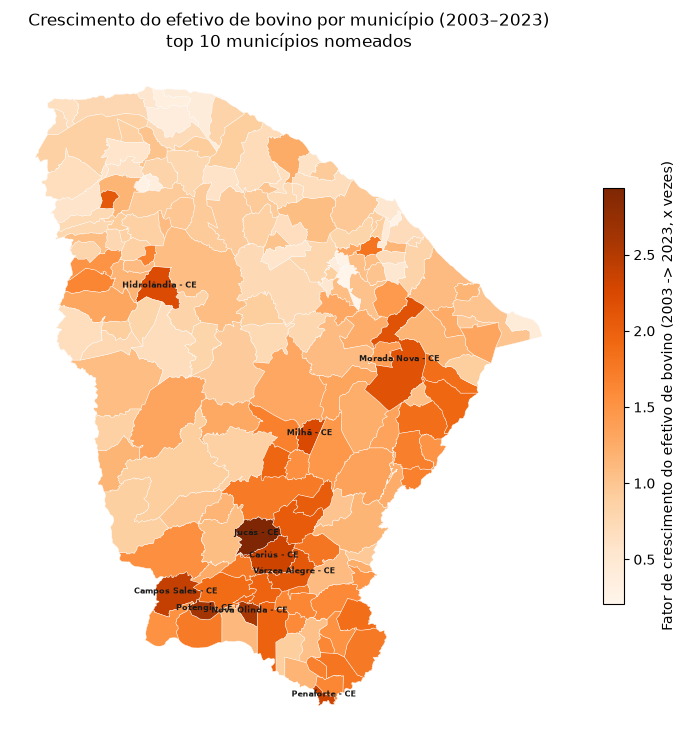

In [9]:
top10_bovino = gdf_bovino.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_bovino.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do efetivo de bovino (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10_bovino.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do efetivo de bovino por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()

## Caprino

Qual foi o efetivo de caprino de cada município do Ceará, e como junto isso com a malha?

In [10]:
caprino_municipios_geo = df_ppm_raw[
    (df_ppm_raw["nivel_territorial_nome"] == "Município")
    & (df_ppm_raw["tipo_rebanho_nome"] == "Caprino")
].copy()
caprino_municipios_geo["territorio_codigo"] = caprino_municipios_geo["territorio_codigo"].astype(str)

caprino_municipios_geo_pivot = caprino_municipios_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

print(f"Municípios com efetivo de caprino: {caprino_municipios_geo_pivot.shape[1]}")
caprino_municipios_geo_pivot.head()

Municípios com efetivo de caprino: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,280.0,45.0,1948.0,8118.0,12315.0,613.0,267.0,5705.0,4650.0,1025.0,...,2014.0,643.0,1057.0,2237.0,1144.0,263.0,7022.0,1248.0,1610.0,8372.0
2004,290.0,103.0,2026.0,8224.0,12362.0,625.0,295.0,5836.0,4743.0,1101.0,...,2054.0,669.0,1162.0,2371.0,1190.0,271.0,7162.0,1425.0,1630.0,9150.0
2005,303.0,118.0,2120.0,8118.0,12415.0,650.0,311.0,5952.0,5000.0,1167.0,...,2137.0,702.0,1243.0,2489.0,1244.0,279.0,7284.0,1539.0,1597.0,8418.0
2006,318.0,123.0,2173.0,8199.0,12579.0,673.0,332.0,6012.0,5075.0,1192.0,...,2202.0,730.0,1620.0,2601.0,1281.0,287.0,7299.0,1710.0,1572.0,8950.0
2007,333.0,131.0,2130.0,8117.0,12797.0,701.0,364.0,9034.0,5278.0,1262.0,...,2265.0,759.0,1800.0,2705.0,1332.0,298.0,7318.0,1980.0,3536.0,9230.0


In [11]:
gdf_caprino = gdf_municipios.merge(
    caprino_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios_caprino = (
    caprino_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_caprino.insert(1, "nome", gdf_caprino["codarea"].map(nomes_municipios_caprino))

nao_casaram = gdf_caprino[gdf_caprino[2023].isna()]
print(f"Municípios sem valor casado: {len(nao_casaram)}")
gdf_caprino.head()

Municípios sem valor casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",280.0,290.0,303.0,318.0,333.0,352.0,368.0,...,591.0,597.0,320.0,340.0,1000.0,1250.0,1230.0,1240.0,1140.0,1215.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",45.0,103.0,118.0,123.0,131.0,141.0,155.0,...,220.0,230.0,300.0,185.0,192.0,200.0,195.0,204.0,180.0,175.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",1948.0,2026.0,2120.0,2173.0,2130.0,2225.0,2358.0,...,2818.0,2820.0,2798.0,1959.0,1950.0,1940.0,1785.0,1749.0,1714.0,1680.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",8118.0,8224.0,8118.0,8199.0,8117.0,7955.0,7875.0,...,6435.0,5791.0,5919.0,6900.0,7000.0,8596.0,9000.0,7470.0,5632.0,5204.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",12315.0,12362.0,12415.0,12579.0,12797.0,12815.0,12996.0,...,30311.0,30350.0,37500.0,46875.0,47675.0,50060.0,46000.0,49957.0,53852.0,45774.0


Como o efetivo de caprino se distribui no mapa, em 2023?

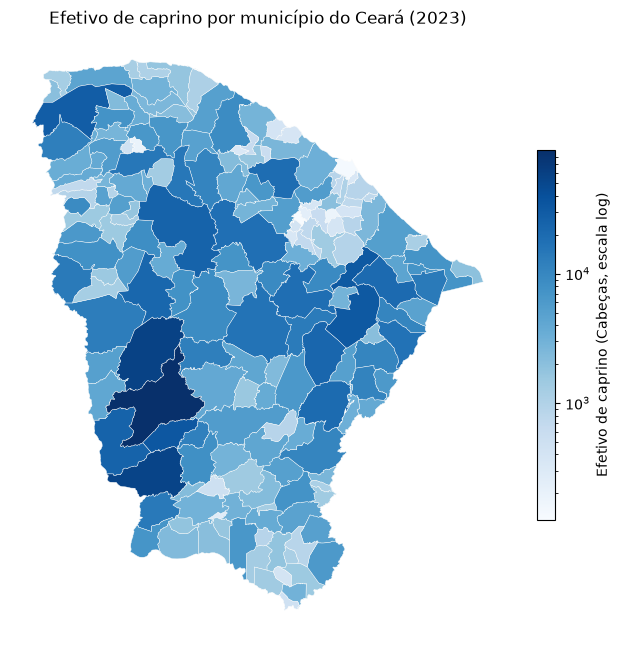

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_caprino.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_caprino[2023][gdf_caprino[2023] > 0].min(), vmax=gdf_caprino[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de caprino (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de caprino por município do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

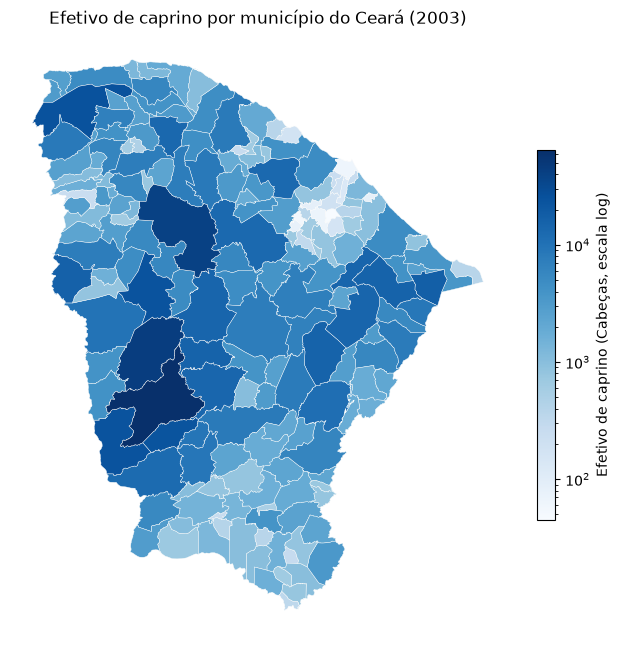

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_caprino.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_caprino[2003][gdf_caprino[2003] > 0].min(), vmax=gdf_caprino[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de caprino (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de caprino por município do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em efetivo de caprino (2003 -> 2023), no mapa?

In [14]:
gdf_caprino["crescimento"] = gdf_caprino[2023] / gdf_caprino[2003]

ranking_caprino = gdf_caprino[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking_caprino.index += 1

print("Ranking de crescimento do efetivo de caprino por município (2003 -> 2023):")
for pos, row in ranking_caprino.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

Ranking de crescimento do efetivo de caprino por município (2003 -> 2023):
  1. Guaiúba - CE                     10.2x
  2. Redenção - CE                     9.2x
  3. Pindoretama - CE                  9.1x
  4. Itaitinga - CE                    8.2x
  5. Maranguape - CE                   7.0x
  6. Crato - CE                        6.6x
  7. Iracema - CE                      6.1x
  8. Mulungu - CE                      5.2x
  9. Icapuí - CE                       4.9x
 10. Aiuaba - CE                       4.4x
 11. Groaíras - CE                     4.3x
 12. Palmácia - CE                     4.3x
 13. Nova Olinda - CE                  4.1x
 14. Abaiara - CE                      4.1x
 15. Acarape - CE                      4.0x
 16. Lavras da Mangabeira - CE         4.0x
 17. Jati - CE                         3.8x
 18. São Benedito - CE                 3.7x
 19. Ubajara - CE                      3.6x
 20. Maracanaú - CE                    3.6x
 21. Pacatuba - CE                     3.5x
 

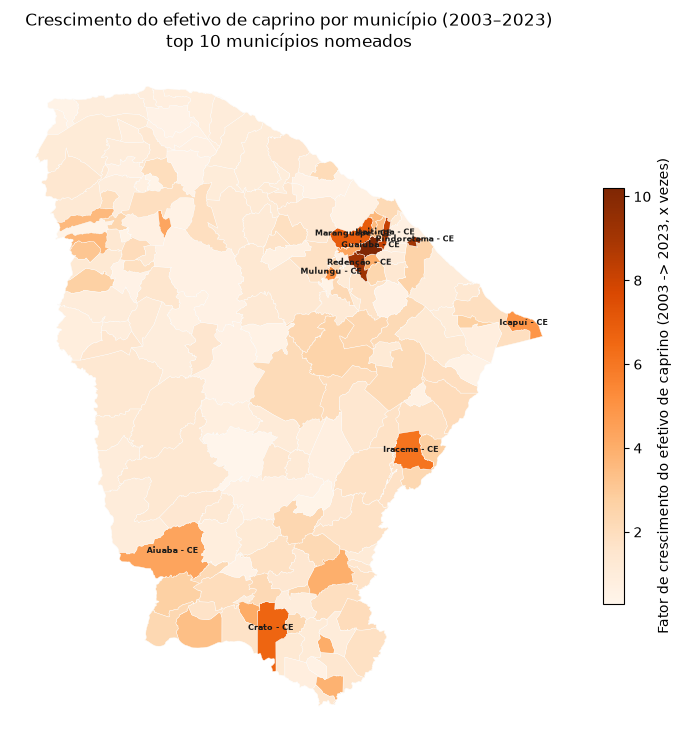

In [15]:
top10_caprino = gdf_caprino.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_caprino.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do efetivo de caprino (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10_caprino.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do efetivo de caprino por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()

## Ovino

Qual foi o efetivo de ovino de cada município do Ceará, e como junto isso com a malha?

In [16]:
ovino_municipios_geo = df_ppm_raw[
    (df_ppm_raw["nivel_territorial_nome"] == "Município")
    & (df_ppm_raw["tipo_rebanho_nome"] == "Ovino")
].copy()
ovino_municipios_geo["territorio_codigo"] = ovino_municipios_geo["territorio_codigo"].astype(str)

ovino_municipios_geo_pivot = ovino_municipios_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

print(f"Municípios com efetivo de ovino: {ovino_municipios_geo_pivot.shape[1]}")
ovino_municipios_geo_pivot.head()

Municípios com efetivo de ovino: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,278.0,360.0,7084.0,19087.0,18372.0,41.0,78.0,11463.0,9376.0,2911.0,...,4012.0,622.0,399.0,4008.0,1773.0,260.0,3257.0,1766.0,2980.0,2643.0
2004,285.0,374.0,7262.0,19392.0,18761.0,42.0,159.0,11693.0,9620.0,3079.0,...,4132.0,653.0,422.0,4248.0,1862.0,270.0,3322.0,1920.0,3015.0,2800.0
2005,295.0,391.0,7588.0,19401.0,19507.0,45.0,174.0,11926.0,10000.0,3242.0,...,4320.0,686.0,388.0,4460.0,1927.0,281.0,3362.0,1843.0,2954.0,2688.0
2006,303.0,409.0,7778.0,19711.0,21392.0,67.0,191.0,12105.0,10250.0,3353.0,...,4493.0,720.0,480.0,4680.0,1985.0,292.0,3387.0,1915.0,2975.0,2878.0
2007,310.0,431.0,7625.0,19513.0,22415.0,60.0,377.0,15171.0,10711.0,3427.0,...,4675.0,756.0,650.0,4867.0,2084.0,306.0,3403.0,2150.0,2945.0,2950.0


In [17]:
gdf_ovino = gdf_municipios.merge(
    ovino_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios_ovino = (
    ovino_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_ovino.insert(1, "nome", gdf_ovino["codarea"].map(nomes_municipios_ovino))

nao_casaram = gdf_ovino[gdf_ovino[2023].isna()]
print(f"Municípios sem valor casado: {len(nao_casaram)}")
gdf_ovino.head()

Municípios sem valor casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",278.0,285.0,295.0,303.0,310.0,320.0,327.0,...,475.0,600.0,1000.0,1060.0,5000.0,5250.0,5335.0,4300.0,4000.0,4400.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",360.0,374.0,391.0,409.0,431.0,451.0,474.0,...,540.0,530.0,600.0,385.0,400.0,416.0,425.0,446.0,400.0,388.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",7084.0,7262.0,7588.0,7778.0,7625.0,7991.0,8550.0,...,10250.0,10256.0,10236.0,8189.0,8149.0,8108.0,7459.0,7384.0,7310.0,7237.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",19087.0,19392.0,19401.0,19711.0,19513.0,19366.0,19172.0,...,23280.0,22814.0,17723.0,17850.0,21420.0,32117.0,33500.0,29480.0,25559.0,23284.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",18372.0,18761.0,19507.0,21392.0,22415.0,22794.0,23142.0,...,49816.0,49900.0,51035.0,63794.0,60606.0,63600.0,57876.0,62340.0,66695.0,79367.0


Como o efetivo de ovino se distribui no mapa, em 2023?

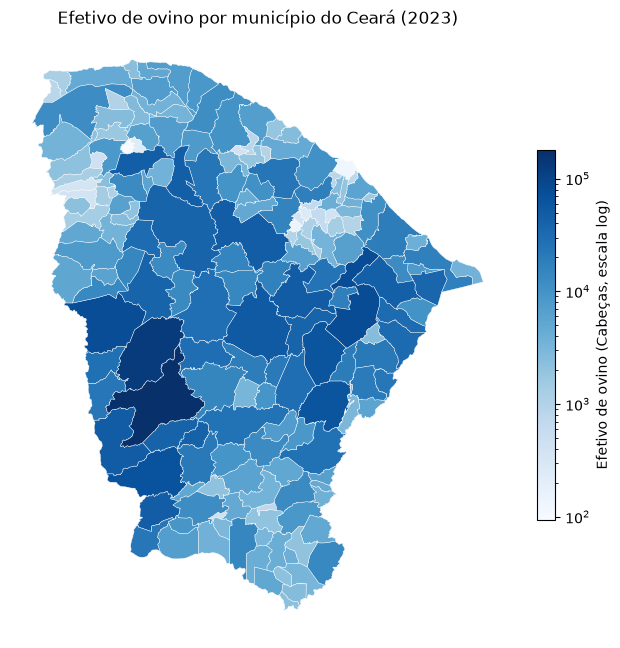

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_ovino.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_ovino[2023][gdf_ovino[2023] > 0].min(), vmax=gdf_ovino[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de ovino (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de ovino por município do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

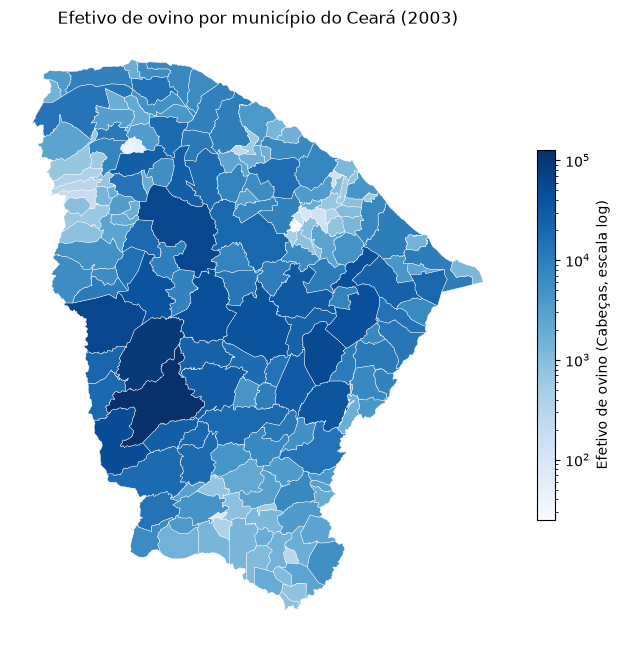

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_ovino.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_ovino[2003][gdf_ovino[2003] > 0].min(), vmax=gdf_ovino[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de ovino (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de ovino por município do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em efetivo de ovino (2003 -> 2023), no mapa?

In [20]:
gdf_ovino["crescimento"] = gdf_ovino[2023] / gdf_ovino[2003]

ranking_ovino = gdf_ovino[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking_ovino.index += 1

print("Ranking de crescimento do efetivo de ovino por município (2003 -> 2023):")
for pos, row in ranking_ovino.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

Ranking de crescimento do efetivo de ovino por município (2003 -> 2023):
  1. Abaiara - CE                     14.4x
  2. Crato - CE                       11.0x
  3. Nova Olinda - CE                  7.6x
  4. Maracanaú - CE                    6.1x
  5. Guaiúba - CE                      6.0x
  6. Croatá - CE                       5.8x
  7. Altaneira - CE                    5.8x
  8. Mulungu - CE                      5.8x
  9. Farias Brito - CE                 5.6x
 10. Maranguape - CE                   5.0x
 11. Araripe - CE                      4.6x
 12. Redenção - CE                     4.5x
 13. Meruoca - CE                      4.4x
 14. Horizonte - CE                    4.2x
 15. Salitre - CE                      3.7x
 16. Barbalha - CE                     3.7x
 17. Aiuaba - CE                       3.6x
 18. Campos Sales - CE                 3.4x
 19. Itaitinga - CE                    3.3x
 20. Itaiçaba - CE                     3.2x
 21. Ubajara - CE                      3.2x
 22

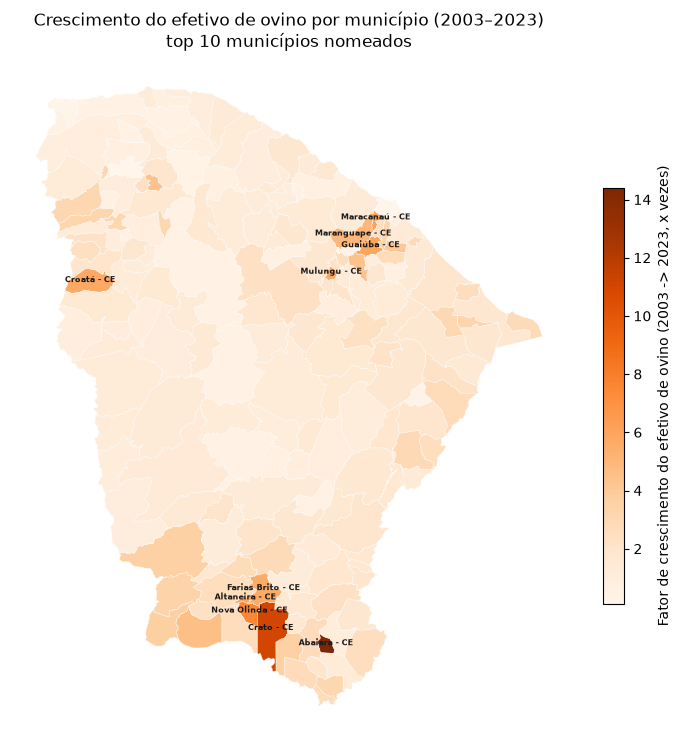

In [21]:
top10_ovino = gdf_ovino.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_ovino.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do efetivo de ovino (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10_ovino.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do efetivo de ovino por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()

## Suíno

Qual foi o efetivo de suíno de cada município do Ceará, e como junto isso com a malha?

In [22]:
suino_municipios_geo = df_ppm_raw[
    (df_ppm_raw["nivel_territorial_nome"] == "Município")
    & (df_ppm_raw["tipo_rebanho_nome"] == "Suíno - total")
].copy()
suino_municipios_geo["territorio_codigo"] = suino_municipios_geo["territorio_codigo"].astype(str)

suino_municipios_geo_pivot = suino_municipios_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

print(f"Municípios com efetivo de suíno: {suino_municipios_geo_pivot.shape[1]}")
suino_municipios_geo_pivot.head()

Municípios com efetivo de suíno: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,539.0,1896.0,8237.0,22158.0,7073.0,2801.0,886.0,3134.0,6504.0,830.0,...,4803.0,1699.0,5744.0,2361.0,1902.0,1453.0,8846.0,2003.0,10000.0,27234.0
2004,555.0,1916.0,8044.0,22507.0,7232.0,2857.0,912.0,3168.0,6178.0,873.0,...,4609.0,1765.0,6080.0,2435.0,1974.0,1509.0,8951.0,2300.0,10000.0,25830.0
2005,574.0,1942.0,8164.0,21858.0,7133.0,2840.0,935.0,3213.0,6266.0,871.0,...,4657.0,1817.0,5737.0,2487.0,2048.0,1569.0,9033.0,2389.0,9811.0,23829.0
2006,587.0,1970.0,8140.0,21537.0,7444.0,2875.0,946.0,3306.0,6363.0,883.0,...,4678.0,1872.0,6370.0,2539.0,2105.0,1632.0,9052.0,2318.0,9761.0,24190.0
2007,600.0,2006.0,7898.0,18952.0,7359.0,2880.0,945.0,6479.0,6010.0,874.0,...,4726.0,1942.0,7550.0,2567.0,2179.0,1694.0,9079.0,2450.0,9272.0,26700.0


In [23]:
gdf_suino = gdf_municipios.merge(
    suino_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios_suino = (
    suino_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_suino.insert(1, "nome", gdf_suino["codarea"].map(nomes_municipios_suino))

nao_casaram = gdf_suino[gdf_suino[2023].isna()]
print(f"Municípios sem valor casado: {len(nao_casaram)}")
gdf_suino.head()

Municípios sem valor casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",539.0,555.0,574.0,587.0,600.0,619.0,632.0,...,761.0,871.0,690.0,992.0,2500.0,2750.0,2820.0,2540.0,2000.0,2035.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",1896.0,1916.0,1942.0,1970.0,2006.0,2047.0,2100.0,...,2189.0,2200.0,430.0,450.0,474.0,499.0,510.0,331.0,550.0,600.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",8237.0,8044.0,8164.0,8140.0,7898.0,8027.0,8206.0,...,2954.0,2948.0,2956.0,3547.0,3618.0,3636.0,3345.0,3278.0,3212.0,3179.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",22158.0,22507.0,21858.0,21537.0,18952.0,16677.0,15842.0,...,12447.0,10579.0,10573.0,11000.0,10000.0,15000.0,22500.0,23400.0,21622.0,27136.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",7073.0,7232.0,7133.0,7444.0,7359.0,7658.0,7763.0,...,3400.0,2380.0,4625.0,4870.0,4770.0,4530.0,4710.0,5166.0,6020.0,7103.0


Como o efetivo de suíno se distribui no mapa, em 2023?

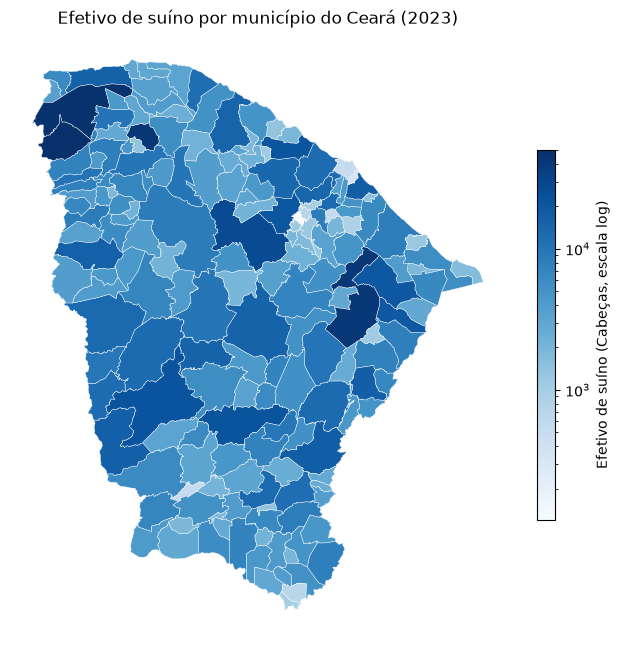

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_suino.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_suino[2023][gdf_suino[2023] > 0].min(), vmax=gdf_suino[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de suíno (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de suíno por município do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

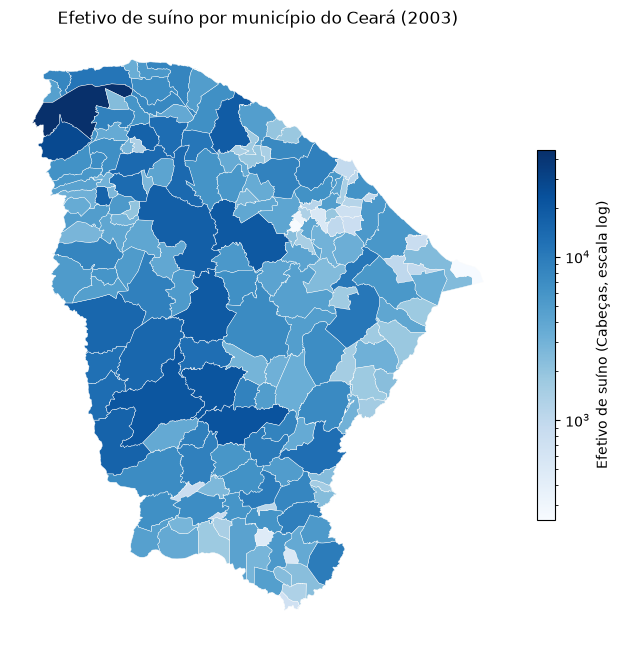

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_suino.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_suino[2003][gdf_suino[2003] > 0].min(), vmax=gdf_suino[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de suíno (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de suíno por município do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em efetivo de suíno (2003 -> 2023), no mapa?

In [26]:
gdf_suino["crescimento"] = gdf_suino[2023] / gdf_suino[2003]

ranking_suino = gdf_suino[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking_suino.index += 1

print("Ranking de crescimento do efetivo de suíno por município (2003 -> 2023):")
for pos, row in ranking_suino.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

Ranking de crescimento do efetivo de suíno por município (2003 -> 2023):
  1. Redenção - CE                    16.0x
  2. Iracema - CE                      9.7x
  3. Icapuí - CE                       6.6x
  4. Pacajus - CE                      6.0x
  5. Caridade - CE                     5.1x
  6. Limoeiro do Norte - CE            4.8x
  7. Mulungu - CE                      4.7x
  8. Juazeiro do Norte - CE            4.6x
  9. Tabuleiro do Norte - CE           4.4x
 10. Horizonte - CE                    4.2x
 11. Palhano - CE                      3.9x
 12. Morada Nova - CE                  3.8x
 13. Abaiara - CE                      3.7x
 14. Russas - CE                       3.5x
 15. Santana do Cariri - CE            3.4x
 16. Ereré - CE                        3.2x
 17. Itaitinga - CE                    2.9x
 18. Potiretama - CE                   2.9x
 19. São Gonçalo do Amarante - CE      2.8x
 20. Aquiraz - CE                      2.8x
 21. Guaiúba - CE                      2.6x
 22

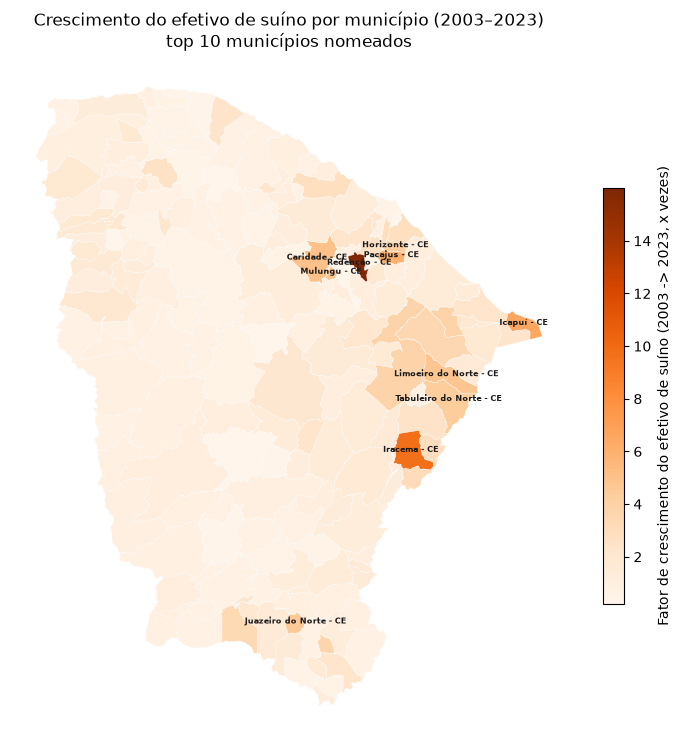

In [27]:
top10_suino = gdf_suino.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_suino.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do efetivo de suíno (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10_suino.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do efetivo de suíno por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()

## Galináceos

Qual foi o efetivo de galináceos de cada município do Ceará, e como junto isso com a malha?

In [28]:
galinaceos_municipios_geo = df_ppm_raw[
    (df_ppm_raw["nivel_territorial_nome"] == "Município")
    & (df_ppm_raw["tipo_rebanho_nome"] == "Galináceos - total")
].copy()
galinaceos_municipios_geo["territorio_codigo"] = galinaceos_municipios_geo["territorio_codigo"].astype(str)

galinaceos_municipios_geo_pivot = galinaceos_municipios_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

print(f"Municípios com efetivo de galináceos: {galinaceos_municipios_geo_pivot.shape[1]}")
galinaceos_municipios_geo_pivot.head()

Municípios com efetivo de galináceos: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,25403.0,2105.0,86321.0,344986.0,33788.0,36779.0,14247.0,10697.0,61699.0,5410.0,...,45758.0,14268.0,239689.0,16447.0,16048.0,29007.0,26130.0,50487.0,93105.0,127254.0
2004,26484.0,2275.0,85185.0,350749.0,34352.0,37340.0,14247.0,10458.0,60784.0,5716.0,...,111535.0,15087.0,246293.0,16940.0,16808.0,30102.0,26007.0,48900.0,93150.0,124130.0
2005,27762.0,2470.0,85611.0,357533.0,35185.0,35500.0,14108.0,10672.0,61392.0,5778.0,...,112092.0,15595.0,150506.0,17278.0,17312.0,31239.0,25923.0,44823.0,91287.0,113703.0
2006,28866.0,2675.0,87946.0,359718.0,36810.0,34784.0,14283.0,10913.0,61479.0,5878.0,...,112257.0,16022.0,135420.0,17577.0,17785.0,31864.0,25993.0,44250.0,91565.0,117482.0
2007,30095.0,2900.0,85490.0,316551.0,37014.0,34794.0,15014.0,29746.0,60683.0,5718.0,...,112485.0,16781.0,167643.0,17752.0,18626.0,33377.0,26013.0,46500.0,86986.0,120500.0


In [29]:
gdf_galinaceos = gdf_municipios.merge(
    galinaceos_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios_galinaceos = (
    galinaceos_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_galinaceos.insert(1, "nome", gdf_galinaceos["codarea"].map(nomes_municipios_galinaceos))

nao_casaram = gdf_galinaceos[gdf_galinaceos[2023].isna()]
print(f"Municípios sem valor casado: {len(nao_casaram)}")
gdf_galinaceos.head()

Municípios sem valor casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",25403.0,26484.0,27762.0,28866.0,30095.0,31677.0,33026.0,...,40802.0,36721.0,245000.0,247000.0,270000.0,273000.0,312000.0,313500.0,302970.0,295764.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",2105.0,2275.0,2470.0,2675.0,2900.0,3140.0,3409.0,...,4480.0,4510.0,20667.0,19604.0,21172.0,22866.0,22408.0,22856.0,24000.0,22500.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",86321.0,85185.0,85611.0,87946.0,85490.0,87203.0,88676.0,...,91928.0,91930.0,91902.0,87307.0,86434.0,87298.0,88171.0,87289.0,86416.0,85552.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",344986.0,350749.0,357533.0,359718.0,316551.0,396178.0,378869.0,...,329301.0,332594.0,495641.0,595000.0,625000.0,1622484.0,1630000.0,1711500.0,1776537.0,2567250.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",33788.0,34352.0,35185.0,36810.0,37014.0,39070.0,40071.0,...,45000.0,31500.0,42161.0,44269.0,46480.0,41830.0,40128.0,41787.0,43876.0,52651.0


Como o efetivo de galináceos se distribui no mapa, em 2023?

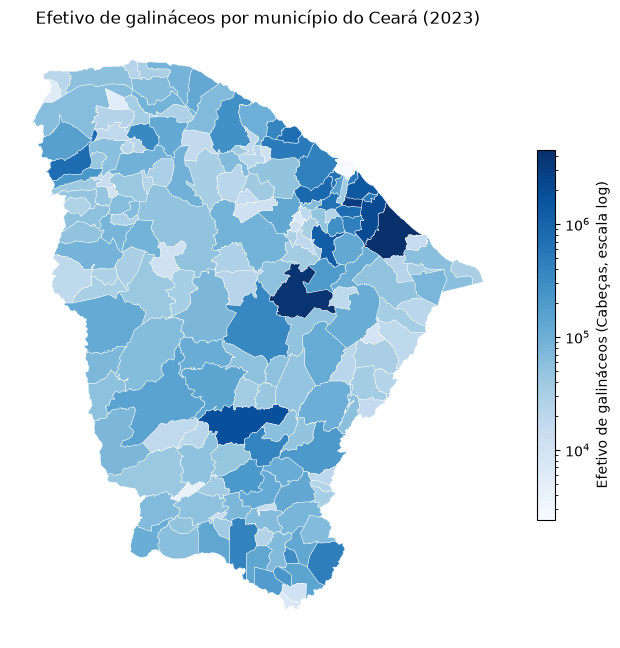

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_galinaceos.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_galinaceos[2023][gdf_galinaceos[2023] > 0].min(), vmax=gdf_galinaceos[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de galináceos (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de galináceos por município do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

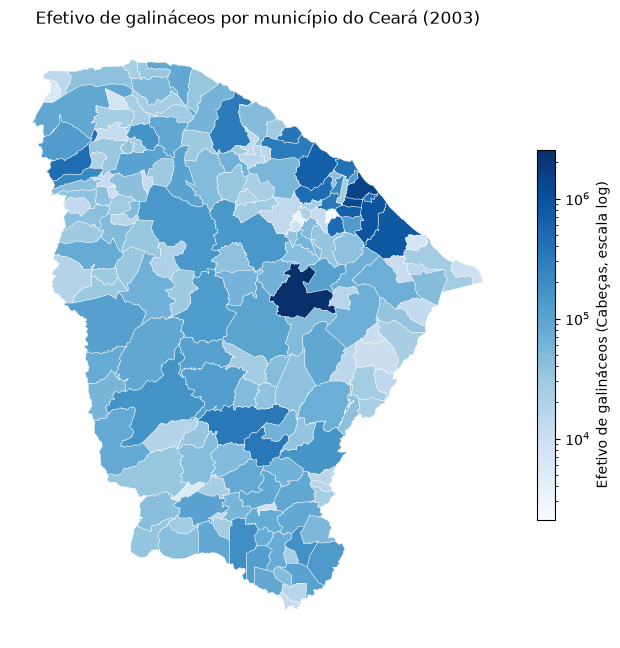

In [31]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_galinaceos.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_galinaceos[2003][gdf_galinaceos[2003] > 0].min(), vmax=gdf_galinaceos[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Efetivo de galináceos (Cabeças, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Efetivo de galináceos por município do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em efetivo de galináceos (2003 -> 2023), no mapa?

In [32]:
gdf_galinaceos["crescimento"] = gdf_galinaceos[2023] / gdf_galinaceos[2003]

ranking_galinaceos = gdf_galinaceos[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking_galinaceos.index += 1

print("Ranking de crescimento do efetivo de galináceos por município (2003 -> 2023):")
for pos, row in ranking_galinaceos.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

Ranking de crescimento do efetivo de galináceos por município (2003 -> 2023):
  1. Aracoiaba - CE                   34.9x
  2. Maracanaú - CE                   14.8x
  3. Paraipaba - CE                   13.0x
  4. Abaiara - CE                     11.9x
  5. Acarape - CE                     11.4x
  6. Caridade - CE                     9.4x
  7. Beberibe - CE                     5.4x
  8. Acopiara - CE                     5.1x
  9. Porteiras - CE                    4.9x
 10. Eusébio - CE                      4.2x
 11. Redenção - CE                     4.1x
 12. Itarema - CE                      3.7x
 13. Quixeramobim - CE                 3.6x
 14. Marco - CE                        3.6x
 15. Chorozinho - CE                   3.5x
 16. Mauriti - CE                      3.3x
 17. Icapuí - CE                       3.2x
 18. Ocara - CE                        3.2x
 19. Salitre - CE                      2.9x
 20. Alto Santo - CE                   2.9x
 21. Palmácia - CE                     2.6

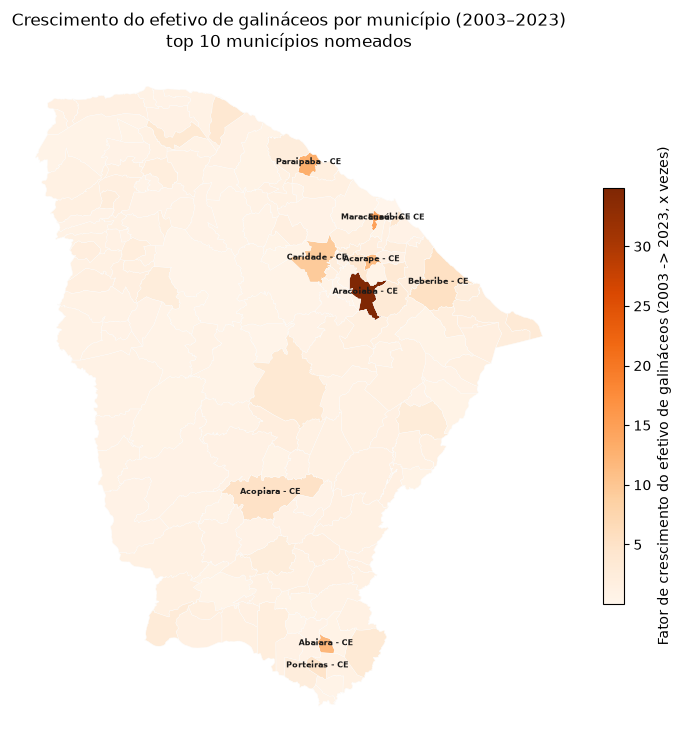

In [33]:
top10_galinaceos = gdf_galinaceos.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_galinaceos.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do efetivo de galináceos (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10_galinaceos.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do efetivo de galináceos por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()